In [5]:
# This code block generates only the density Fourier spectrum n_k
# and the single-particle spectrum stored as results[2][0] for one selected
# parameter point of the interacting disordered Majorana chain.
#
# For a fixed disorder realization and Hamiltonian configuration, it iterates
# the self-consistent mean-field equations, diagonalizes the resulting
# Majorana/BdG Hamiltonian, computes the correlation matrix, and extracts:
#
#   1. n_k             : Fourier transform of the local density n_i
#   2. results[2][0]   : eigenvalues of the final mean-field Hamiltonian
#
# All unused diagnostics from the longer analysis script were removed:
# central charge, entanglement entropy, CDW amplitude, AGR, IPR, curvature,
# plotting, multiprocessing, and BdG consistency checks.

import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import warnings

warnings.filterwarnings("ignore")


# =============================
# Model + MF machinery
# =============================

class System:
    def __init__(self, L, t, mu, W, delta, U, V,
                 disorder, disorder1, disorder_gamma, disorder_eta,
                 npf, pbc, trs, W_ratio):
        # Build convenience arrays
        arr = np.ones(L)
        arr[0] = arr[-1] = pbc

        a1 = 1j * np.block([npf[L - 1] * pbc, npf[0:L - 1]])
        a2 = 1j * np.block([npf[1:L], npf[0] * pbc])
        d  = 1j * npf[3 * L:4 * L] * arr

        b  = 1j * npf[1 * L:2 * L]
        b1 = 1j * np.block([npf[2 * L - 1] * pbc, npf[1 * L:2 * L - 1]])
        b2 = 1j * np.block([npf[1 * L + 1:2 * L], npf[1 * L] * pbc])
        c  = 1j * npf[2 * L:3 * L]

        i_gamma_j_gamma_jplus1 = 1j * npf[4 * L:5 * L]
        i_eta_j_eta_jplus1     = 1j * npf[5 * L:6 * L]

        e1 = np.block([i_eta_j_eta_jplus1[-1], i_eta_j_eta_jplus1[0:L - 1]])
        e2 = np.block([i_eta_j_eta_jplus1[-2], i_eta_j_eta_jplus1[-1], i_eta_j_eta_jplus1[0:L - 2]])
        f1 = np.block([i_gamma_j_gamma_jplus1[-1], i_gamma_j_gamma_jplus1[0:L - 1]])
        f2 = i_gamma_j_gamma_jplus1

        H_mu = (
            -1j * (-W * disorder + mu) * np.eye(L, k=0)
            - U * (a1 + a2) * np.eye(L, k=0)
            - V * d * np.eye(L, k=0)
        )

        H_t = 1j * (-t + delta) * np.eye(L, k=1) - U * b * np.eye(L, k=1)
        H_t[L - 1, 0] = (1j * (-t + delta) - U * b[0]) * pbc

        H_t1 = (
            1j * (-t - delta - W * disorder1) * np.eye(L, k=-1)
            + U * c * np.eye(L, k=-1)
            + V * (b1 + b2) * np.eye(L, k=-1)
        )
        H_t1[0, L - 1] = (
            1j * (-t - delta - W * disorder1[0])
            + U * c[L - 1]
            + V * (b1[L - 1] + b2[L - 1])
        ) * pbc

        H_t2 = V * a2 * np.eye(L, k=-2)
        H_t2[0, L - 2] = V * a2[L - 2] * pbc
        H_t2[1, L - 1] = V * a2[L - 1] * pbc

        H_maj_mf = H_mu + H_t + H_t1 + H_t2

        # TRS-breaking gamma/eta blocks.
        # trs = 0 suppresses these mean-field channels.
        # trs = 1 allows them.
        H_gamma0 = (
            trs * np.eye(L, k=1) * (-U * e1 - V * e2)
            + 1j * np.eye(L, k=1) * W * W_ratio * disorder_gamma
        )
        H_eta0 = (
            trs * np.eye(L, k=1) * (-U * f1 - V * f2)
            + 1j * np.eye(L, k=1) * W * W_ratio * disorder_eta
        )

        H_gamma0[L - 1, 0] = (
            trs * (-U * e1[0] - V * e2[0])
            + 1j * W * W_ratio * disorder_gamma[0]
        ) * pbc
        H_eta0[L - 1, 0] = (
            trs * (-U * f1[0] - V * f2[0])
            + 1j * W * W_ratio * disorder_eta[0]
        ) * pbc

        H_gamma = H_gamma0 - H_gamma0.T
        H_eta   = H_eta0 - H_eta0.T

        H = np.block([
            [H_gamma,          H_maj_mf],
            [H_maj_mf.conj().T, H_eta]
        ])

        self.H = H
        self.L = L

        # Ground-state correlator at T = 0.
        eigvals, eigvecs = np.linalg.eigh(self.H)
        occupation = np.heaviside(-eigvals, 0.5)
        self.gamma_eta = eigvecs.conj() @ np.diag(occupation) @ eigvecs.T

        majorana_to_c = np.sqrt(0.5) * np.block([
            [np.eye(L),      np.eye(L)],
            [1j * np.eye(L), -1j * np.eye(L)]
        ])
        self.nij = majorana_to_c.conj().T @ self.gamma_eta @ majorana_to_c

        self.E = np.sum(eigvals * occupation)

    def calculation_npf(self):
        L = self.L
        gamma_eta = self.gamma_eta[0:L, L:2 * L]

        ai = np.zeros(L)
        bi = np.zeros(L)
        ci = np.zeros(L)
        di = np.zeros(L)
        xi = np.zeros(L)
        yi = np.zeros(L)

        for i in range(L):
            ai[i] = np.real((-1j) * gamma_eta[i, i])
            bi[i] = np.real((1j) * gamma_eta[(i + 1) % L, i])
            ci[i] = np.real((-1j) * gamma_eta[i, (i + 1) % L])
            di[i] = np.real((1j) * gamma_eta[(i + 1) % L, (i - 1) % L])

        gamma_gamma = self.gamma_eta[0:L, 0:L]
        eta_eta     = self.gamma_eta[L:2 * L, L:2 * L]

        for i in range(L):
            xi[i] = np.real((-1j) * gamma_gamma[i, (i + 1) % L])
            yi[i] = np.real((-1j) * eta_eta[i, (i + 1) % L])

        return np.block([ai, bi, ci, di, xi, yi])

    def index_npf(self):
        # Keep the same output structure as in the original notebook.
        # The requested eigenvalue array is therefore still results[2][0].
        w, v = np.linalg.eigh(self.H)
        return (None, None, (w, v), None, None, None, None, None, self.nij, self.E)


# =============================
# User parameters
# =============================

# Set here parameters of the Hamiltonian
L = 200
t0 = 0.5
delta0 = 0.5
mu0 = -(t0 + delta0)

# VY_to_UY_ratio = 1 for the fully critical chain.
# VY_to_UY_ratio = 0 for the Majorana-Hubbard chain.
VY_to_UY_ratio = 0.0

pbc = 0       # open boundary conditions
jj_iter = 800

g = 1.1
WX = 0.3
delta_mf = 1e-3

# trs = 0: mean-field does not break time-reversal symmetry, BDI class.
# trs = 1: allows time-reversal-symmetry-breaking mean-field terms, D class.
trs = 0

# W_ratio controls explicit TRS-breaking disorder in gamma/eta blocks.
W_ratio = 0.0

mf_precision = 1e-9
fric = 0.5


# =============================
# Random seed and disorders
# =============================

seed = 100000
rng = np.random.default_rng(seed)

npf = delta_mf * rng.uniform(-1.0, 1.0, size=6 * L)

UY = 2 * g
VY = VY_to_UY_ratio * UY

dis        = rng.uniform(-1.0, 1.0, size=L)
dis1       = rng.uniform(-1.0, 1.0, size=L)
dis_gamma  = rng.uniform(-1.0, 1.0, size=L)
dis_eta    = rng.uniform(-1.0, 1.0, size=L)


# =============================
# MF iterations
# =============================

jj = 0
while jj < jj_iter:
    sys = System(
        L=L, t=t0, mu=mu0, W=WX, delta=delta0, U=UY, V=VY,
        disorder=dis, disorder1=dis1,
        disorder_gamma=dis_gamma, disorder_eta=dis_eta,
        npf=npf, pbc=pbc, trs=trs, W_ratio=W_ratio
    )

    npf_y = sys.calculation_npf()
    eps = float(np.max(np.abs(npf - npf_y)))

    if eps < mf_precision:
        break

    npf = (1 - fric) * npf_y + fric * npf
    jj += 1

print(f"MF iterations completed: jj = {jj}, eps = {eps:.3e}")


# =============================
# Build the final system and extract requested data
# =============================

# --- build the system and get nij ---
sys = System(
    L=L, t=t0, mu=mu0, W=WX, delta=delta0, U=UY, V=VY,
    disorder=dis, disorder1=dis1,
    disorder_gamma=dis_gamma, disorder_eta=dis_eta,
    npf=npf, pbc=pbc, trs=trs, W_ratio=W_ratio
)

results = sys.index_npf()
nij = results[8]

# Requested spectral data:
# this is exactly the array results[2][0] from the original code.
eig_vals = results[2][0]

# --- extract diagonal density and compute Fourier transform ---
n_i = np.real(np.diag(nij)[:L])
n = n_i

# FFT of n_i.
# rfft is used because n_i is real.
n_k = np.fft.rfft(n)/L
k_vals = 2*np.pi * np.arange(len(n_k)) / (L // 1)


# =============================
# Save only the requested arrays
# =============================

np.save("n_k.npy", n_k)
np.save("eigvals_results_2_0.npy", eig_vals)

print("Saved requested arrays:")
print("  n_k.npy")
print("  eigvals_results_2_0.npy")


MF iterations completed: jj = 800, eps = 3.751e-09
Saved requested arrays:
  n_k.npy
  eigvals_results_2_0.npy


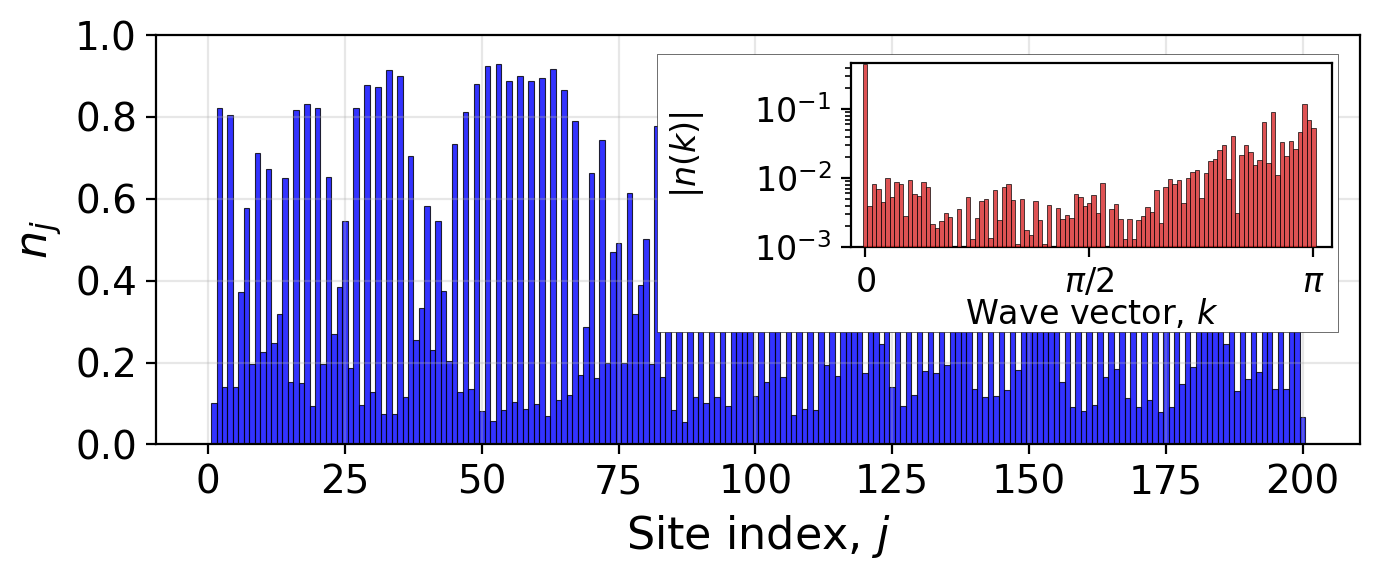

In [6]:
#_______Plotting of the density and structure factor for complex fermion representation________


from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter
import numpy as np
from matplotlib.ticker import FixedLocator

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


plt.rcParams["figure.dpi"] = 200

#____uncomment one of the dataset below_____






fig, ax1 = plt.subplots(figsize=(7, 3))

# main plot
ax1.bar(np.arange(L) + 1, n_i, width=1, color='blue', alpha=0.8,
        edgecolor='k', linewidth=0.4, zorder=1)
ax1.set_xlabel("Site index, $j$", fontsize=16)
ax1.set_ylabel(r"$n_j$", fontsize=16)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.grid(True, alpha=0.3, zorder=0)

# inset (on top)
axins = inset_axes(ax1, width="40%", height="45%", loc='upper right', borderpad=1.0)
axins.set_facecolor('white')         # data area white
axins.patch.set_alpha(1.0)
axins.set_zorder(10)                 # ensure inset is above main plot
axins.bar(k_vals, np.abs(n_k), width=2*np.pi/L, color='tab:red', alpha=0.8,
          edgecolor='k', linewidth=0.3, zorder=11)

axins.tick_params(axis='both', which='major', labelsize=12)
axins.set_xlim(-0.1, np.pi + 2*np.pi/L+0.1)
axins.set_ylim(0.001, )
axins.set_yscale("log")
axins.set_xlabel("Wave vector, $k$", fontsize=12)
axins.set_ylabel("$|n(k)|$", fontsize=12)
axins.yaxis.set_label_coords(-0.3, 0.5)
axins.xaxis.set_label_coords(0.5, -0.27)
ticks = [0, np.pi/2, np.pi]
axins.xaxis.set_major_locator(FixedLocator(ticks))
axins.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$"], fontsize=12)

plt.tight_layout()


fig.canvas.draw()  # need renderer to compute tight bbox
renderer = fig.canvas.get_renderer()
bb_inset = axins.get_tightbbox(renderer)                        # pixels
bb_fig   = bb_inset.transformed(fig.transFigure.inverted())     # to figure [0,1]

pad = 0.004  # small padding around the inset box (figure coords)
white_bg = Rectangle((bb_fig.x0 - 2*pad, bb_fig.y0 - 0.45*pad),
                     bb_fig.width + 3*pad, bb_fig.height + 4*pad,
                     transform=fig.transFigure,
                     facecolor='white', edgecolor='black', linewidth=0.2,
                     zorder=axins.get_zorder()-1, clip_on=False)
fig.add_artist(white_bg)

plt.show()


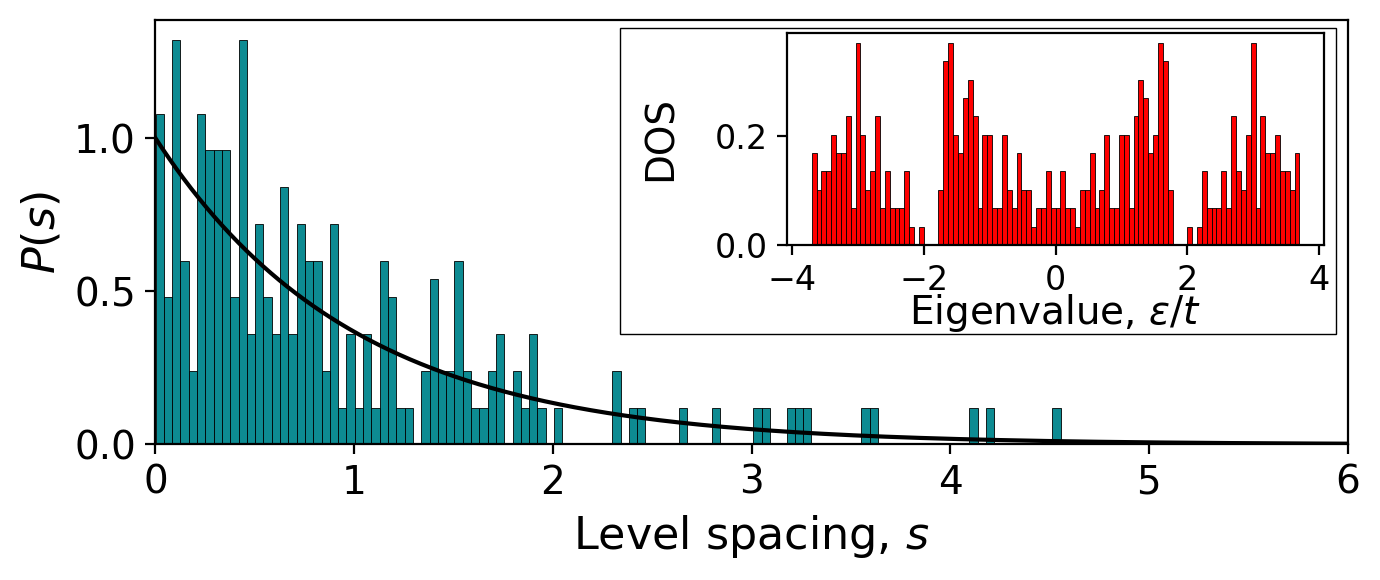

(<Figure size 1400x600 with 1 Axes>,
 <AxesSubplot: xlabel='Level spacing, $s$', ylabel='$P(s)$'>)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 200
#path = Path('wavefunctions_500/').expanduser()


eigvals = eig_vals

def _wd_pdf(s, ensemble="GOE"):
    """
    Wigner–Dyson surmise PDFs for unit-mean spacing s.
    GOE:  P(s) = (π/2) s exp(-π s^2 / 4)
    GUE:  P(s) = (32/π^2) s^2 exp(-4 s^2 / π)
    GSE:  P(s) = (2^18 / (3^6 π^3)) s^4 exp(-64 s^2 / (9π))
    """
    if ensemble.upper() == "GOE":
        return 0.5*np.pi*s*np.exp(-0.25*np.pi*s*s)
    elif ensemble.upper() == "GUE":
        return (32.0/np.pi**2) * (s**2) * np.exp(-4.0*s*s/np.pi)
    elif ensemble.upper() == "GSE":
        return (2.0**18/(3.0**6*np.pi**3)) * (s**4) * np.exp(-64.0*s*s/(9.0*np.pi))
    else:
        raise ValueError("ensemble must be 'GOE', 'GUE', or 'GSE'")

def plot_eigs_hist(
    eigvals,
    mode="auto",           # "auto" | "real" | "imag" | "abs"
    bins=300,             # bins for MAIN (spacing) histogram
    density=True,
    logy=False,
    figsize=(6, 4),        # figure width × height (inches)
    aspect=None,           # e.g. 'equal' or a float (y/x)
    box_aspect=None,       # axes box height/width
    color="#0D8B92",            # color for MAIN histogram (None -> default)
    # ---- inset controls ----
    inset=True,
    inset_rect=(0.62, 0.55, 0.35, 0.35),  # (x0, y0, w, h) in axes coords
    inset_bins=200,        # bins for INSET (spectrum) histogram
    spacing_norm=True,     # normalize spacings to mean 1 (recommended for theory overlays)
    # ---- theory overlays ----
    show_poisson=True,
    show_wigner_dyson=True,
    wd_ensemble="GOE",     # "GOE" (default), "GUE", "GSE"
    main_labelsize=14,
    main_ticksize=12,
    main_titlesize=14,
    legend_size=12,
    inset_labelsize=12,
    inset_ticksize=10,
    tight=True,
    save=None,
    show=True,
):
    """
    Main plot: level-spacing histogram (+ optional Poisson & Wigner–Dyson overlays).
    Inset: spectrum (eigenvalue) histogram.
    """
    eigvals = np.asarray(eigvals).ravel()

    # choose which part to use as the spectrum variable x
    if mode == "real":
        x = np.real(eigvals); mode_shown = "real"
    elif mode == "imag":
        x = np.imag(eigvals); mode_shown = "imag"
    elif mode == "abs":
        x = np.abs(eigvals);  mode_shown = "abs"
    else:  # auto
        if np.iscomplexobj(eigvals) and np.max(np.abs(np.imag(eigvals))) > 1e-10:
            x = np.abs(eigvals); mode_shown = "abs"
        else:
            x = np.real(eigvals); mode_shown = "real"

    x = x[np.isfinite(x)]
    vals = np.sort(x)
    spacings_raw = np.diff(vals)
    s = spacings_raw[spacings_raw > 0]  # drop zeros/negatives
    if s.size == 0:
        s = np.array([0.0])
    mean_s_raw = np.mean(s) if s.size else 1.0
    if spacing_norm and mean_s_raw > 0:
        s = s / mean_s_raw

    # main figure (level spacings)
    fig, ax = plt.subplots(figsize=figsize)
    hist_vals, edges, _ = ax.hist(s, bins=bins,  edgecolor='k', linewidth=0.3, zorder=1, density=density, color=color)

    ax.set_xlabel(r"Level spacing, $s$" + ("" if spacing_norm else " (not normalized)"), fontsize=main_labelsize)
    ax.set_ylabel(r"$P(s)$" if density else "Count", fontsize=main_labelsize)
    ax.tick_params(axis="both", which="both", labelsize=main_ticksize)
    ax.set_xlim(0,6)
    if logy:
        ax.set_yscale("log")
    if aspect is not None:
        ax.set_aspect(aspect, adjustable="box")
    if box_aspect is not None:
        ax.set_box_aspect(box_aspect)

    # ---- theory overlays (auto-scaled to density or counts) ----
    handles = []
    labels = []
    xmin, xmax = ax.get_xlim()
    s_plot = np.linspace(max(0.0, xmin), max(xmax, 1e-8), 1200)

    # If spacings are not normalized, rescale the *input* to PDFs by mean spacing
    # so that theory curves appear at the correct x-locations.
    s_for_pdf = s_plot if spacing_norm or mean_s_raw <= 0 else (s_plot / mean_s_raw)

    # Scale theory curves to match histogram y-units:
    # density -> 1, counts -> N * binwidth
    N = len(s)
    binwidth = np.mean(np.diff(edges))
    theory_scale = 1.0 if density else (N * binwidth)

    if show_poisson:
        P_poiss = np.exp(-s_for_pdf)           # Poisson: P(s) = e^{-s}
        h_poiss, = ax.plot(s_plot, theory_scale * P_poiss, color="black", label="Poisson")
        handles.append(h_poiss); labels.append("Poisson")

    if show_wigner_dyson:
        P_wd = _wd_pdf(s_for_pdf, ensemble=wd_ensemble)
        h_wd, = ax.plot(s_plot, theory_scale * P_wd, color="black", label=f"Wigner–Dyson ({wd_ensemble.upper()})")
        handles.append(h_wd); labels.append(f"Wigner–Dyson ({wd_ensemble.upper()})")

    #if handles:
    #    ax.legend(handles=handles, labels=labels, fontsize=12, frameon=True)

    # ---- inset: spectrum histogram ----
    if inset:
        x0, y0, w, h = inset_rect
        pad = 0.02
        bg = plt.Rectangle(
            (x0 - 7*pad, y0 - 10.5*pad), w + 7.5*pad, h + 11*pad,
            transform=ax.transAxes, facecolor="white", edgecolor="black",
            linewidth=0.5, zorder=2, clip_on=False
        )
        ax.add_patch(bg)

        axins = ax.inset_axes([x0, y0, w, h], zorder=3, facecolor="white")
        axins.hist(x, bins=inset_bins, color="red",  edgecolor='k', linewidth=0.3, zorder=1, density=True)
        #axins.set_title("Spectrum", fontsize=8, pad=2)
        axins.tick_params(axis="both", which="both", labelsize=12)
        axins.set_ylabel(r"DOS", fontsize=inset_labelsize)
        axins.set_xlabel(r"Eigenvalue, $\epsilon/t$", fontsize=inset_labelsize)
        axins.yaxis.set_label_coords(-0.2, 0.5)
        axins.xaxis.set_label_coords(0.5, -0.22)
        for spine in axins.spines.values():
            spine.set_linewidth(0.8)

    if tight:
        fig.tight_layout()
    if save:
        fig.savefig(save, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

# Example call
plot_eigs_hist(
    eigvals,
    mode="auto",
    bins=300,               # MAIN (spacing) histogram bins
    density=True,          # keep True for direct PDF comparison
    figsize=(7, 3),
    inset=True,
    inset_rect=(0.53, 0.47, 0.45, 0.5),
    inset_bins= 100, #GOE        # INSET (spectrum) histogram bins
    spacing_norm=True,     # normalize to mean spacing 1 (matches theory)
    show_poisson=True,
    show_wigner_dyson=False,
    wd_ensemble="GOE",
    main_labelsize=16,
    main_ticksize=14,
    main_titlesize=14,
    legend_size=12,
    inset_labelsize=14,
    inset_ticksize=14
)
